# Baseline model for batch monitoring example

In [6]:
import requests
import datetime
import pandas as pd

# from evidently import ColumnMapping
# from evidently.pipeline.column_mapping import ColumnMapping
# from evidently.report import Report
# from evidently.metrics import ColumnDriftMetric, DatasetDriftMetric, DatasetMissingValuesMetric

from joblib import load, dump
from tqdm import tqdm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [ ]:
# files = [('green_tripdata_2022-02.parquet', './data'), ('green_tripdata_2022-01.parquet', './data')]
files = [("green_tripdata_2024-03.parquet", "../data")]

print("Download files:")
for file, path in files:
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{file}"
    resp = requests.get(url, stream=True)
    save_path = f"{path}/{file}"
    with open(save_path, "wb") as handle:
        for data in tqdm(
            resp.iter_content(),
            desc=f"{file}",
            postfix=f"save to {save_path}",
            total=int(resp.headers["Content-Length"]),
        ):
            handle.write(data)

Download files:


green_tripdata_2024-03.parquet: 100%|██████████| 1372372/1372372 [00:08<00:00, 164156.03it/s, save to ../data/green_tripdata_2024-03.parquet]


In [ ]:
file, path = files[0]
jan_data = pd.read_parquet(f"{path}/{file}")

In [14]:
jan_data.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,57457.000000,57457,57457,55360.000000,57457.000000,57457.000000,55360.000000,57457.000000,57457.000000,57457.000000,57457.000000,57457.000000,57457.000000,0.0,57457.000000,57457.000000,55360.000000,55353.000000,55360.000000
mean,1.877334,2024-03-16 04:02:52.405399,2024-03-16 04:21:00.076039,1.179986,95.524688,138.629149,1.309538,13.522828,17.313474,0.904472,0.577410,2.386255,0.192537,NaN,0.979378,22.904832,1.321062,1.038047,0.737730
min,1.000000,2008-12-31 23:02:24,2008-12-31 23:02:30,1.000000,1.000000,1.000000,0.000000,0.000000,-295.080000,-2.500000,-0.500000,-1.560000,0.000000,NaN,-1.000000,-296.080000,1.000000,1.000000,-2.750000
25%,2.000000,2024-03-08 13:53:56,2024-03-08 14:13:49,1.000000,74.000000,74.000000,1.000000,1.100000,9.300000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,13.440000,1.000000,1.000000,0.000000
50%,2.000000,2024-03-15 22:49:01,2024-03-15 23:09:52,1.000000,75.000000,138.000000,1.000000,1.790000,13.500000,0.000000,0.500000,2.000000,0.000000,NaN,1.000000,18.500000,1.000000,1.000000,0.000000
75%,2.000000,2024-03-23 20:11:25,2024-03-23 20:34:48,1.000000,97.000000,220.000000,1.000000,3.100000,19.800000,1.000000,0.500000,3.610000,0.000000,NaN,1.000000,27.050000,2.000000,1.000000,2.750000
max,2.000000,2024-04-01 00:01:45,2024-04-01 16:11:00,99.000000,265.000000,265.000000,9.000000,125112.200000,841.600000,10.000000,4.250000,150.000000,26.760000,NaN,1.000000,856.980000,5.000000,2.000000,2.750000
std,0.328056,NaN,NaN,1.356719,57.285088,76.295346,0.967749,770.416255,14.958249,1.382446,0.366916,3.159273,1.184551,NaN,0.154253,17.013735,0.497858,0.191311,1.218039


In [15]:
jan_data.shape

(57457, 20)

In [ ]:
# create target
jan_data["duration_min"] = (
    jan_data.lpep_dropoff_datetime - jan_data.lpep_pickup_datetime
)
jan_data.duration_min = jan_data.duration_min.apply(
    lambda td: float(td.total_seconds()) / 60
)

In [17]:
# filter out outliers
jan_data = jan_data[(jan_data.duration_min >= 0) & (jan_data.duration_min <= 60)]
jan_data = jan_data[(jan_data.passenger_count > 0) & (jan_data.passenger_count <= 8)]

<Axes: >

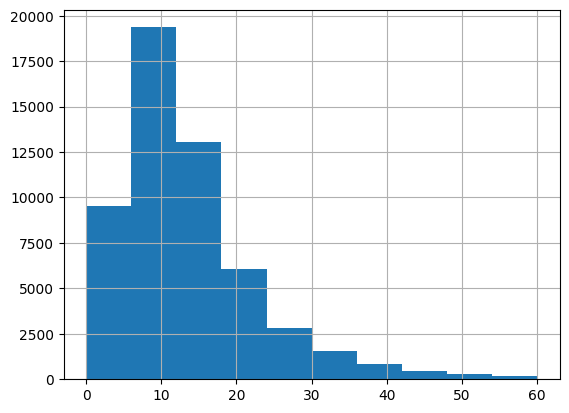

In [18]:
jan_data.duration_min.hist()

In [19]:
# data labeling
target = "duration_min"
num_features = ["passenger_count", "trip_distance", "fare_amount", "total_amount"]
cat_features = ["PULocationID", "DOLocationID"]

In [20]:
jan_data.shape

(54135, 21)

In [ ]:
train_data = jan_data[:30000]
val_data = jan_data[30000:]

model = LinearRegression()
model.fit(train_data[num_features + cat_features], train_data[target])

In [ ]:
train_data["prediction"] = model.predict(train_data[num_features + cat_features])
val_data["prediction"] = model.predict(val_data[num_features + cat_features])

In [26]:
print(mean_absolute_error(train_data.duration_min, train_data.prediction))
print(mean_absolute_error(val_data.duration_min, val_data.prediction))

3.7724732393594484
3.716814567929369


# Dump model and reference data

In [ ]:
with open("models/lin_reg.bin", "wb") as f_out:
    dump(model, f_out)

In [ ]:
val_data.to_parquet("data/reference.parquet")

# Evidently Report

In [ ]:
from evidently import Dataset
from evidently import DataDefinition
from evidently import Report
from evidently.presets import DataDriftPreset, DataSummaryPreset

In [36]:
# column_mapping = ColumnMapping(
#     target=None,
#     prediction="prediction",
#     numerical_features=num_features,
#     categorical_features=cat_features,
# )

In [58]:
# report = Report(
#     metrics=[
#         ColumnDriftMetric(column_name="prediction"),
#         DatasetDriftMetric(),
#         DatasetMissingValuesMetric(),
#     ]
# )

report = Report([DataDriftPreset(columns=[*num_features, *cat_features, "prediction"])])
# report = Report([DataDriftPreset(columns=["prediction"])])
report_result = report.run(reference_data=train_data, current_data=val_data)
report_result

c:\Program Files\Python312\Lib\site-packages\evidently\core\datasets.py:990: RuntimeWarning:

invalid value encountered in scalar divide

c:\Program Files\Python312\Lib\site-packages\evidently\core\datasets.py:990: RuntimeWarning:

invalid value encountered in scalar divide



In [59]:
result = report_result.dict()

In [60]:
result

{'metrics': [{'id': '2e90a5de4047a18664d8dcf7e09f7217',
   'metric_id': 'DriftedColumnsCount(columns=passenger_count,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID,prediction,drift_share=0.5)',
   'value': {'count': 0.0, 'share': 0.0}},
  {'id': '627ecbd85d0104676b00bedba97a4a20',
   'metric_id': 'ValueDrift(column=passenger_count)',
   'value': 0.01166869846342269},
  {'id': '32bb865e004396989318986fca20adc1',
   'metric_id': 'ValueDrift(column=trip_distance)',
   'value': 0.014304387983719951},
  {'id': 'f6e3fad8f5b0bc4766dea6099806687e',
   'metric_id': 'ValueDrift(column=fare_amount)',
   'value': 0.009230886280531437},
  {'id': '7d630f15834f8c59e4ee21d6b907dc1a',
   'metric_id': 'ValueDrift(column=total_amount)',
   'value': 0.01152354781267549},
  {'id': '55ac0d3ab973e295b757b905344717f8',
   'metric_id': 'ValueDrift(column=PULocationID)',
   'value': 0.017885235031276942},
  {'id': '4982f3e54d389610ea57eac0b6f86a8d',
   'metric_id': 'ValueDrift(column=DOLocatio

In [61]:
# prediction drift
# result["metrics"][0]["result"]["drift_score"]
result["metrics"][-1]["value"]

0.010064593780096763

In [66]:
# number of drifted columns
# result["metrics"][1]["result"]["number_of_drifted_columns"]
result["metrics"][0]['value']['count']

0.0

In [67]:
# share of missing values
# result["metrics"][2]["result"]["current"]["share_of_missing_values"]

# Evidently Dashboard

In [90]:
from evidently.presets import DataDriftPreset

from evidently.ui.workspace import Workspace
# from evidently.ui.dashboards import (
#     DashboardPanelCounter,
#     DashboardPanelPlot,
#     CounterAgg,
#     PanelValue,
#     PlotType,
#     ReportFilter,
# )
# from evidently.renderers.html_widgets import WidgetSize

In [71]:
ws = Workspace("workspace")

In [72]:
project = ws.create_project("NYC Taxi Data Quality Project")
project.description = "My project descriotion"
project.save()

In [ ]:
# regular_report = Report(
#     metrics=[
#         DataQualityPreset()
#     ],
#     timestamp=datetime.datetime(2022,1,28)
# )

# regular_report.run(reference_data=None,
#                   current_data=val_data.loc[val_data.lpep_pickup_datetime.between('2022-01-28', '2022-01-29', inclusive="left")],
#                   column_mapping=column_mapping)

regular_report = Report(
    metrics=[
        DataSummaryPreset(
            columns=[*num_features, *cat_features, "prediction"],
            # timestamp=datetime.datetime(2024, 3, 28),
        )
    ],
)

regular_report.run(
    current_data=val_data.loc[
        val_data.lpep_pickup_datetime.between(
            "2024-03-28", "2024-03-29", inclusive="left"
        )
    ]
)

regular_report

c:\Program Files\Python312\Lib\site-packages\evidently\core\datasets.py:990: RuntimeWarning:

invalid value encountered in scalar divide



In [89]:
ws.add_report(project.id, regular_report)

AttributeError: 'Workspace' object has no attribute 'add_report'

In [ ]:
# configure the dashboard
project.dashboard.add_panel(
    DashboardPanelCounter(
        filter=ReportFilter(metadata_values={}, tag_values=[]),
        agg=CounterAgg.NONE,
        title="NYC taxi data dashboard",
    )
)

project.dashboard.add_panel(
    DashboardPanelPlot(
        filter=ReportFilter(metadata_values={}, tag_values=[]),
        title="Inference Count",
        values=[
            PanelValue(
                metric_id="DatasetSummaryMetric",
                field_path="current.number_of_rows",
                legend="count",
            ),
        ],
        plot_type=PlotType.BAR,
        size=WidgetSize.HALF,
    ),
)

project.dashboard.add_panel(
    DashboardPanelPlot(
        filter=ReportFilter(metadata_values={}, tag_values=[]),
        title="Number of Missing Values",
        values=[
            PanelValue(
                metric_id="DatasetSummaryMetric",
                field_path="current.number_of_missing_values",
                legend="count",
            ),
        ],
        plot_type=PlotType.LINE,
        size=WidgetSize.HALF,
    ),
)

project.save()

Project(id=UUID('fae27da1-1efd-4a08-82f7-ae423b64d123'), name='NYC Taxi Data Quality Project', description='My project descriotion', dashboard=DashboardConfig(name='NYC Taxi Data Quality Project', panels=[DashboardPanelCounter(type='evidently.ui.dashboards.reports.DashboardPanelCounter', id=UUID('f86ffa03-5059-4320-8de7-efc23a227c4c'), title='NYC taxi data dashboard', filter=ReportFilter(metadata_values={}, tag_values=[], include_test_suites=False), size=<WidgetSize.FULL: 2>, agg=<CounterAgg.NONE: 'none'>, value=None, text=None), DashboardPanelPlot(type='evidently.ui.dashboards.reports.DashboardPanelPlot', id=UUID('ffdef20b-0e95-4a3a-b925-24df3a7450b3'), title='Inference Count', filter=ReportFilter(metadata_values={}, tag_values=[], include_test_suites=False), size=<WidgetSize.HALF: 1>, values=[PanelValue(field_path='current.number_of_rows', metric_id='DatasetSummaryMetric', metric_hash=None, metric_args={}, legend='count')], plot_type=<PlotType.BAR: 'bar'>), DashboardPanelPlot(type='e

In [ ]:
regular_report = Report(
    metrics=[DataQualityPreset()], timestamp=datetime.datetime(2022, 1, 29)
)

regular_report.run(
    reference_data=None,
    current_data=val_data.loc[
        val_data.lpep_pickup_datetime.between(
            "2022-01-29", "2022-01-30", inclusive="left"
        )
    ],
    column_mapping=column_mapping,
)

regular_report

In [37]:
ws.add_report(project.id, regular_report)